# BRCA1 Sequence Analysis with Biopython

This project retrieves the human **BRCA1 reference transcript** from NCBI and uses Biopython to examine sequence composition, GC content, motifs, coding sequence, and translated protein.

**Skills demonstrated:** biological data retrieval, sequence analysis, Python, Biopython, pandas, and data visualization.

In [1]:
!pip -q install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 18.9 MB/s eta 0:00:00


In [2]:
from Bio import SeqIO
from Bio.SeqUtils import gc_fraction
from collections import Counter
from urllib.request import urlopen
from io import TextIOWrapper
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

## 1. Retrieve the BRCA1 record from NCBI

In [3]:
accession = 'NM_007294.4'
url = f'https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id={accession}&rettype=gb&retmode=text'

with urlopen(url) as response:
    record = SeqIO.read(TextIOWrapper(response), 'genbank')

print(f'Accession: {record.id}')
print(f'Description: {record.description}')
print(f'Sequence length: {len(record.seq):,} nucleotides')

Accession: NM_007294.4
Description: Homo sapiens BRCA1 DNA repair associated (BRCA1), transcript variant 1, mRNA
Sequence length: 7,088 nucleotides


## 2. Calculate nucleotide composition and GC content

In [4]:
sequence = record.seq.upper()
counts = Counter(str(sequence))
gc_percent = gc_fraction(sequence) * 100

summary = pd.DataFrame({
    'Metric': ['Sequence length', 'A', 'T', 'G', 'C', 'GC content (%)'],
    'Value': [len(sequence), counts['A'], counts['T'], counts['G'], counts['C'], round(gc_percent, 2)]
})
summary

,Metric,Value
0,Sequence length,7088.00
1,A,2368.00
2,T,1759.00
3,G,1585.00
4,C,1376.00
5,GC content (%),41.77


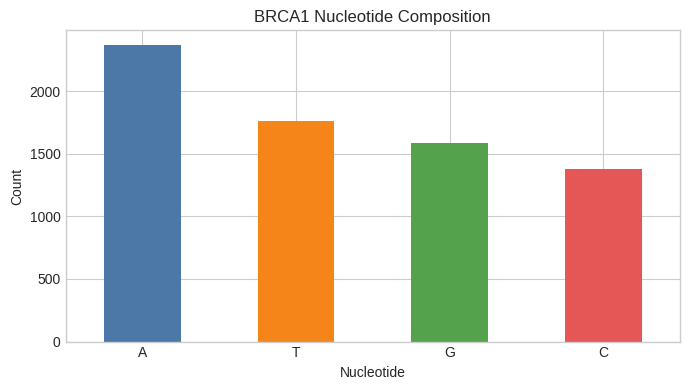

In [5]:
base_counts = pd.Series({base: counts[base] for base in 'ATGC'})
colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756']
ax = base_counts.plot(kind='bar', color=colors, figsize=(7, 4))
ax.set(title='BRCA1 Nucleotide Composition', xlabel='Nucleotide', ylabel='Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Visualize GC content across the transcript

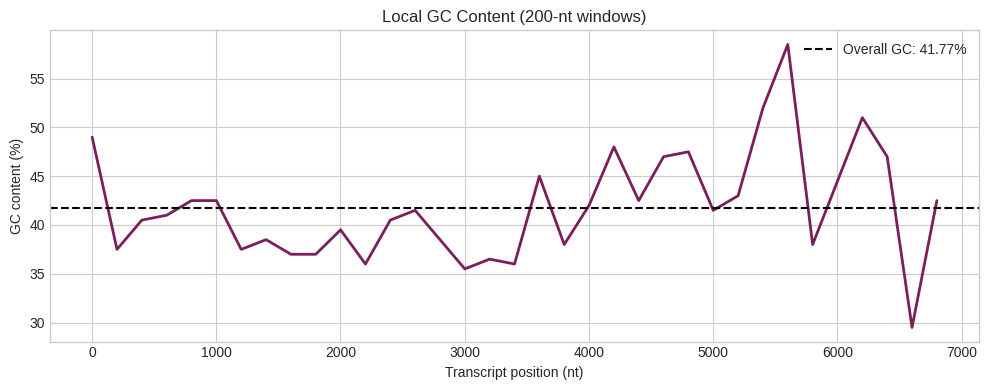

In [6]:
window_size = 200
positions = []
window_gc = []

for start in range(0, len(sequence) - window_size + 1, window_size):
    window = sequence[start:start + window_size]
    positions.append(start + 1)
    window_gc.append(gc_fraction(window) * 100)

plt.figure(figsize=(10, 4))
plt.plot(positions, window_gc, color='#7A1F5C', linewidth=2)
plt.axhline(gc_percent, color='black', linestyle='--', label=f'Overall GC: {gc_percent:.2f}%')
plt.xlabel('Transcript position (nt)')
plt.ylabel('GC content (%)')
plt.title(f'Local GC Content ({window_size}-nt windows)')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Search for biologically relevant sequence motifs

In [7]:
motifs = {
    'Start codon': 'ATG',
    'Stop codon (TAA)': 'TAA',
    'Stop codon (TAG)': 'TAG',
    'Stop codon (TGA)': 'TGA',
    'Polyadenylation signal': 'AATAAA'
}

motif_results = []
for name, motif in motifs.items():
    positions_found = []
    start = 0
    while True:
        position = str(sequence).find(motif, start)
        if position == -1:
            break
        positions_found.append(position + 1)
        start = position + 1
    motif_results.append({
        'Motif type': name,
        'Sequence': motif,
        'Count': len(positions_found),
        'First five positions': positions_found[:5]
    })

motif_df = pd.DataFrame(motif_results)
motif_df

,Motif type,Sequence,Count,First five positions
0,Start codon,ATG,140,"[114, 151, 160, 165, 255]"
1,Stop codon (TAA),TAA,137,"[45, 90, 158, 305, 316]"
2,Stop codon (TAG),TAG,84,"[178, 350, 902, 1009, 1051]"
3,Stop codon (TGA),TGA,181,"[3, 137, 202, 230, 259]"
4,Polyadenylation signal,AATAAA,9,"[1029, 1611, 1776, 2508, 3018]"


## 5. Extract the annotated coding sequence and translate it

In [8]:
cds_feature = next(feature for feature in record.features if feature.type == 'CDS')
coding_dna = cds_feature.extract(record.seq)
protein = coding_dna.translate(to_stop=True)

print(f'Coding DNA length: {len(coding_dna):,} nucleotides')
print(f'Protein length: {len(protein):,} amino acids')
print(f'First 60 amino acids: {protein[:60]}')

Coding DNA length: 5,592 nucleotides
Protein length: 1,863 amino acids
First 60 amino acids: MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFCMLKLLNQKKGPSQ


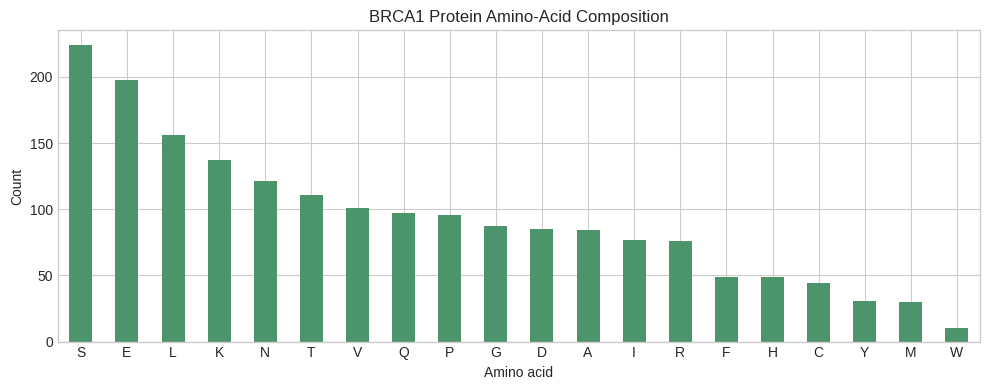

In [9]:
amino_acid_counts = pd.Series(Counter(str(protein))).sort_values(ascending=False)
ax = amino_acid_counts.plot(kind='bar', figsize=(10, 4), color='#4C956C')
ax.set(title='BRCA1 Protein Amino-Acid Composition', xlabel='Amino acid', ylabel='Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Biological interpretation

- GC content summarizes the proportion of guanine and cytosine in the transcript and can influence sequence stability and molecular behavior.
- Sliding-window analysis shows that nucleotide composition is not uniform across the transcript.
- Motif searching identifies candidate codons and the polyadenylation signal, although true functional interpretation depends on annotation and sequence context.
- Extracting the annotated CDS avoids assuming that every ATG marks the true translation start.
- The translated BRCA1 protein is rich in several amino acids and can be examined further for domains, variants, or evolutionary conservation.

## 7. Export the results

In [10]:
summary.to_csv('brca1_sequence_summary.csv', index=False)
motif_df.to_csv('brca1_motif_results.csv', index=False)
SeqIO.write(record, 'brca1_record.gb', 'genbank')
print('Files exported successfully.')

Files exported successfully.


## Limitations and next steps

This is an introductory sequence-level analysis of one reference transcript. It does not evaluate patient variants or clinical significance. Future work could compare BRCA1 orthologs, map known variants, or examine conserved protein domains.